<a href="https://colab.research.google.com/github/AliefReefandi/Practical-Statistics-for-Data-Scientists/blob/main/Chapter_6_Statistical_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6 — Statistical Machine Learning

## 1. Tujuan Pembelajaran

Pada chapter ini akan dipelajari beberapa metode Statistical Machine Learning
untuk melakukan prediksi, khususnya pada masalah klasifikasi dan regresi.

Tujuan pembelajaran:
- Memahami konsep K-Nearest Neighbors (KNN).
- Memahami pentingnya distance metrics dan standardisasi data pada KNN.
- Memahami konsep Decision Tree.
- Memahami konsep Bagging dan Random Forest.
- Memahami variable importance.
- Memahami hyperparameters dalam machine learning.
- Memahami konsep Boosting dan XGBoost.
- Memahami masalah overfitting dan regularization.
- Memahami penggunaan cross-validation untuk pemilihan model dan parameter.

## 2. Ringkasan Chapter

Statistical Machine Learning merupakan pendekatan untuk membuat model prediksi
yang lebih fleksibel dan banyak bergantung pada pola yang terdapat pada data.

Berbeda dengan pendekatan statistik klasik yang sering menggunakan struktur
model tertentu, machine learning lebih berfokus pada kemampuan model dalam
mempelajari pola dari data dan menghasilkan prediksi.

Chapter ini membahas beberapa metode utama:

1. K-Nearest Neighbors (KNN)
2. Decision Tree
3. Bagging
4. Random Forest
5. Variable Importance
6. Boosting
7. XGBoost
8. Regularization
9. Hyperparameter dan Cross-Validation

Contoh yang digunakan dalam chapter adalah data pinjaman (loan data), terutama
untuk memprediksi apakah sebuah pinjaman akan mengalami default atau tidak.

## 3. Konsep Teoritis
## 3.1 K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) adalah metode machine learning yang melakukan prediksi
berdasarkan kemiripan antara sebuah data dengan data lainnya.

Cara kerja KNN:

1. Tentukan nilai K.
2. Hitung jarak antara data yang ingin diprediksi dengan data training.
3. Pilih K data yang memiliki jarak paling dekat.
4. Untuk klasifikasi, gunakan kelas mayoritas dari K tetangga tersebut.
5. Untuk regresi, gunakan rata-rata nilai dari K tetangga.

Contohnya, jika K = 5, maka model akan mencari 5 data yang paling mirip dengan
data baru dan menggunakan informasi dari kelima data tersebut untuk menentukan
prediksi.

KNN sangat bergantung pada pengukuran jarak. Oleh karena itu, skala setiap
variabel perlu diperhatikan.

In [3]:
import pandas as pd

loan_data = pd.read_csv('loan_data.csv.gz')

loan_data.head()

,Unnamed: 0,status,loan_amnt,term,annual_inc,dti,payment_inc_ratio,revol_bal,revol_util,purpose,...,delinq_2yrs_zero,pub_rec_zero,open_acc,grade,outcome,emp_length,purpose_,home_,emp_len_,borrower_score
0,1,Charged Off,2500,60 months,30000,1.00,2.39320,1687,9.4,car,...,1,1,3,4.8,default,1,major_purchase,RENT,> 1 Year,0.65
1,2,Charged Off,5600,60 months,40000,5.55,4.57170,5210,32.6,small_business,...,1,1,11,1.4,default,5,small_business,OWN,> 1 Year,0.80
2,3,Charged Off,5375,60 months,15000,18.08,9.71600,9279,36.5,other,...,1,1,2,6.0,default,1,other,RENT,> 1 Year,0.60
3,4,Charged Off,9000,36 months,30000,10.08,12.21520,10452,91.7,debt_consolidation,...,1,1,4,4.2,default,1,debt_consolidation,RENT,> 1 Year,0.50
4,5,Charged Off,10000,36 months,100000,7.06,3.90888,11997,55.5,other,...,1,1,14,5.4,default,4,other,RENT,> 1 Year,0.55


In [4]:
loan_data.columns.tolist()

['Unnamed: 0',
 'status',
 'loan_amnt',
 'term',
 'annual_inc',
 'dti',
 'payment_inc_ratio',
 'revol_bal',
 'revol_util',
 'purpose',
 'home_ownership',
 'delinq_2yrs_zero',
 'pub_rec_zero',
 'open_acc',
 'grade',
 'outcome',
 'emp_length',
 'purpose_',
 'home_',
 'emp_len_',
 'borrower_score']

In [5]:
from sklearn.neighbors import KNeighborsClassifier

predictors = [
    'payment_inc_ratio',
    'dti',
    'revol_bal',
    'revol_util'
]

outcome = 'outcome'

newloan = loan_data.loc[0:0, predictors]
X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

nbrs = knn.kneighbors(newloan)

X.iloc[nbrs[1][0], :]

,payment_inc_ratio,dti,revol_bal,revol_util
35536,1.47212,1.46,1686,10.0
33651,3.38178,6.37,1688,8.4
25863,2.36303,1.39,1691,3.5
42953,1.28160,7.14,1684,3.9
43599,4.12244,8.98,1684,7.2


### Analisis

Model mencari 5 data yang memiliki karakteristik paling dekat dengan data pinjaman
yang ingin diprediksi.

Pada contoh ini terlihat bahwa KNN menggunakan jarak antar-record untuk menentukan
tetangga terdekat. Namun, terdapat masalah ketika variabel memiliki skala yang
berbeda jauh, misalnya `revol_bal` memiliki nilai dalam satuan dolar sedangkan
variabel lainnya memiliki nilai yang jauh lebih kecil.

Karena itu, standardisasi diperlukan sebelum menerapkan KNN.

## 3.2 Standardization pada KNN

Standardisasi mengubah nilai variabel sehingga memiliki skala yang lebih sebanding.

Hal ini penting untuk KNN karena algoritma menggunakan jarak.

Jika satu variabel memiliki angka yang jauh lebih besar dibandingkan variabel lain,
variabel tersebut dapat mendominasi perhitungan jarak.

Standardisasi yang umum digunakan adalah z-score:

z = (x - mean) / standard deviation

Setelah dilakukan standardisasi, KNN dapat menghitung jarak dengan lebih adil
antar-variabel.

In [6]:
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier

newloan = loan_data.loc[0:0, predictors]
X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

scaler = preprocessing.StandardScaler()

scaler.fit(X * 1.0)

X_std = scaler.transform(X * 1.0)
newloan_std = scaler.transform(newloan * 1.0)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_std, y)

nbrs = knn.kneighbors(newloan_std)

X.iloc[nbrs[1][0], :]

,payment_inc_ratio,dti,revol_bal,revol_util
2080,2.61091,1.03,1218,9.7
1438,2.34343,0.51,278,9.9
30215,2.71200,1.34,1075,8.5
28542,2.39760,0.74,2917,7.4
44737,2.34309,1.37,488,7.2


### Analisis

Setelah standardisasi, setiap variabel memiliki skala yang lebih sebanding.

Hal ini membuat hasil pencarian tetangga menjadi lebih masuk akal karena jarak
tidak lagi didominasi oleh variabel dengan nilai numerik yang besar.

Buku juga menjelaskan bahwa pemilihan nilai K sangat penting. Nilai K yang terlalu
kecil dapat menyebabkan overfitting, sedangkan nilai K yang terlalu besar dapat
membuat model terlalu halus dan kehilangan pola lokal pada data.

## 3.3 Tree Models

Decision Tree atau Tree Model adalah model yang menggunakan aturan bercabang
untuk membagi data menjadi beberapa kelompok.

Bentuk sederhananya dapat dibayangkan seperti:

Jika kondisi A benar:
    lanjut ke cabang kiri

Jika kondisi A salah:
    lanjut ke cabang kanan

Beberapa istilah penting:

- Root: titik awal dari tree.
- Node: bagian tempat dilakukan pembagian data.
- Split value: nilai yang digunakan untuk membagi data.
- Leaf: bagian akhir dari tree yang menghasilkan prediksi.
- Impurity: ukuran seberapa bercampur kelas dalam suatu kelompok.
- Pruning: proses mengurangi cabang tree untuk menghindari overfitting.

Kelebihan decision tree adalah aturan yang dihasilkan relatif mudah dipahami.

In [8]:
# Membuat sample 3.000 data dari loan_data
loan3000 = loan_data.sample(
    n=3000,
    random_state=1
).copy()

loan3000.head()

,Unnamed: 0,status,loan_amnt,term,annual_inc,dti,payment_inc_ratio,revol_bal,revol_util,purpose,...,delinq_2yrs_zero,pub_rec_zero,open_acc,grade,outcome,emp_length,purpose_,home_,emp_len_,borrower_score
35896,35897,Fully Paid,10000,36 months,50000,14.78,8.38824,9526,73.2,credit_card,...,0,1,7,3.6,paid off,3,credit_card,RENT,> 1 Year,0.45
34867,34868,Fully Paid,6500,36 months,59280,24.73,4.11721,4858,62.3,debt_consolidation,...,1,1,13,6.8,paid off,6,debt_consolidation,RENT,> 1 Year,0.55
31852,31853,Fully Paid,6000,36 months,50000,9.33,5.28216,5446,85.1,other,...,1,1,7,3.8,paid off,6,other,MORTGAGE,> 1 Year,0.55
28318,28319,Fully Paid,10825,36 months,80000,33.40,5.08080,61952,64.4,debt_consolidation,...,1,1,17,6.8,paid off,10,debt_consolidation,MORTGAGE,> 1 Year,0.60
42655,42656,Fully Paid,15000,36 months,90000,6.93,6.78613,23062,71.8,other,...,1,1,10,4.2,paid off,5,other,MORTGAGE,> 1 Year,0.45


In [9]:
loan3000.shape

(3000, 21)

In [10]:
from sklearn.tree import DecisionTreeClassifier

predictors = [
    'borrower_score',
    'payment_inc_ratio'
]

outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

loan_tree = DecisionTreeClassifier(
    random_state=1,
    criterion='entropy',
    min_impurity_decrease=0.003
)

loan_tree.fit(X, y)

DecisionTreeClassifier(criterion='entropy', min_impurity_decrease=0.003,
                       random_state=1)

## 3.4 Bagging dan Random Forest

Bagging atau Bootstrap Aggregating adalah metode ensemble yang menggunakan
beberapa model dan menggabungkan hasil prediksinya.

Ide dasarnya:

1. Ambil beberapa sampel data menggunakan bootstrap.
2. Buat model pada setiap sampel.
3. Gabungkan hasil dari seluruh model.

Random Forest merupakan pengembangan dari bagging menggunakan decision tree.

Selain melakukan bootstrap terhadap record, Random Forest juga memilih subset
variabel secara acak pada setiap proses pembagian tree.

Dengan menggunakan banyak tree, Random Forest dapat menghasilkan prediksi yang
lebih stabil dibandingkan hanya menggunakan satu decision tree.

In [11]:
from sklearn.ensemble import RandomForestClassifier

predictors = [
    'borrower_score',
    'payment_inc_ratio'
]

outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=1,
    oob_score=True
)

rf.fit(X, y)

print("OOB Score:", rf.oob_score_)

OOB Score: 0.5433333333333333


### Analisis

`n_estimators=500` berarti model membangun 500 decision tree.

`oob_score=True` digunakan untuk menghitung Out-of-Bag (OOB) score.

OOB merupakan estimasi performa model menggunakan data yang tidak digunakan
dalam bootstrap sample untuk tree tertentu.

Dengan demikian, Random Forest dapat memperoleh estimasi performa tanpa harus
menggunakan data tambahan secara khusus untuk setiap tree.

## 3.5 Variable Importance

Random Forest dapat digunakan untuk melihat seberapa penting suatu variabel
dalam menghasilkan prediksi.

Salah satu informasi yang tersedia pada `RandomForestClassifier` adalah
`feature_importances_`.

Nilai ini menunjukkan kontribusi relatif setiap variabel terhadap model.

Semakin besar nilainya, semakin besar kontribusi variabel tersebut dalam proses
pembentukan tree berdasarkan ukuran importance yang digunakan model.

In [13]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance

,Feature,Importance
0,borrower_score,0.104628
1,payment_inc_ratio,0.895372


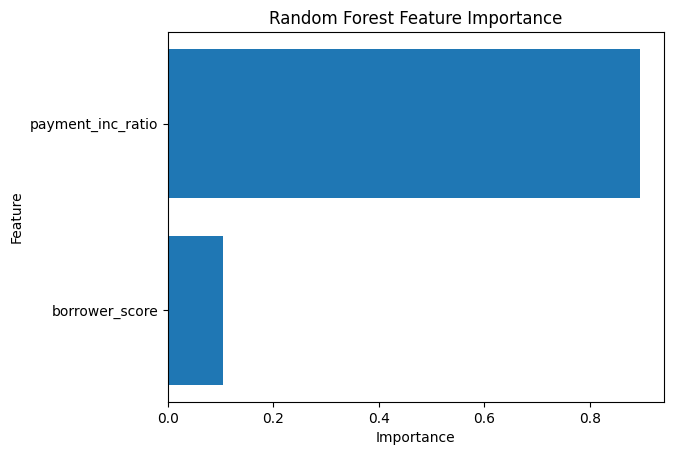

In [14]:
import matplotlib.pyplot as plt

importance_sorted = importance.sort_values(
    by='Importance',
    ascending=True
)

plt.barh(
    importance_sorted['Feature'],
    importance_sorted['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')

plt.show()

## 3.6 Hyperparameters

Hyperparameter adalah parameter yang ditentukan sebelum proses training model.

Contoh hyperparameter pada Random Forest:

- `n_estimators` → jumlah tree.
- `max_depth` → kedalaman maksimum tree.
- `min_samples_split` → jumlah minimum data untuk melakukan split.
- `max_features` → jumlah variabel yang dipertimbangkan pada setiap split.

Pemilihan hyperparameter dapat memengaruhi performa model.

Model yang terlalu kompleks dapat mengalami overfitting, sedangkan model yang
terlalu sederhana dapat mengalami underfitting.

Karena itu, hyperparameter biasanya dipilih menggunakan validation atau
cross-validation.

## 3.7 Boosting

Boosting merupakan metode ensemble yang membangun model secara berurutan.

Berbeda dengan bagging yang membuat banyak model secara relatif independen,
boosting menggunakan hasil dari model sebelumnya untuk membantu membangun model
berikutnya.

Secara sederhana:

Model 1 → menemukan kesalahan
       ↓
Model 2 → lebih memperhatikan kesalahan tersebut
       ↓
Model 3 → memperbaiki kesalahan sebelumnya
       ↓
Gabungkan seluruh model

Tujuannya adalah menghasilkan model prediksi yang lebih kuat.

Boosting dapat menghasilkan model yang sangat baik, tetapi juga memiliki risiko
overfitting sehingga hyperparameter perlu diperhatikan.

## 3.8 XGBoost

XGBoost adalah implementasi boosting yang populer dan efisien.

XGBoost menggunakan konsep stochastic gradient boosting dan menyediakan berbagai
parameter yang dapat disesuaikan.

Beberapa parameter penting:

- `n_estimators` → jumlah tree.
- `max_depth` → kedalaman tree.
- `learning_rate` → mengontrol seberapa besar kontribusi setiap tree.
- `subsample` → proporsi data yang digunakan pada setiap iterasi.
- `reg_alpha` → regularization L1.
- `reg_lambda` → regularization L2.

Dalam implementasi Python, parameter `eta` yang digunakan dalam pembahasan
XGBoost disebut `learning_rate` pada scikit-learn API.

In [16]:
from xgboost import XGBClassifier

predictors = [
    'borrower_score',
    'payment_inc_ratio'
]

outcome = 'outcome'

X = loan3000[predictors]

# Ubah outcome menjadi 0 dan 1
y = (loan3000[outcome] == 'default').astype(int)

xgb = XGBClassifier(
    objective='binary:logistic',
    subsample=0.63
)

xgb.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [17]:
print(y.unique())

[0 1]


In [18]:
pred = xgb.predict_proba(X)[:, 1]

pred[:10]

array([0.3896864 , 0.13603859, 0.44526923, 0.24911603, 0.45187372,
       0.6009243 , 0.51277024, 0.9408143 , 0.29703054, 0.68846637],
      dtype=float32)

### Analisis

XGBoost menghasilkan probabilitas prediksi untuk setiap record.

Parameter `subsample=0.63` berarti sekitar 63% observasi digunakan pada setiap
iterasi boosting.

Penggunaan sampling dan pengaturan learning rate dapat membantu mengurangi
risiko overfitting.

## 3.9 Regularization dan Overfitting

Overfitting terjadi ketika model terlalu menyesuaikan diri dengan data training
sehingga performanya pada data baru menjadi lebih buruk.

Hal ini menjadi salah satu perhatian penting pada boosting.

Regularization digunakan untuk memberikan penalti terhadap model yang terlalu
kompleks.

Pada XGBoost terdapat dua parameter regularization:

- `reg_alpha` → regularization L1.
- `reg_lambda` → regularization L2.

Meningkatkan regularization dapat mengurangi kompleksitas model dan membantu
mengendalikan overfitting.

In [19]:
xgb_penalty = XGBClassifier(
    objective='binary:logistic',
    n_estimators=250,
    max_depth=6,
    reg_lambda=1000,
    learning_rate=0.1,
    subsample=0.63
)

xgb_penalty.fit(X, y)

pred_penalty = xgb_penalty.predict_proba(X)[:, 1]

pred_penalty[:10]

array([0.61016375, 0.33783543, 0.34935954, 0.31369627, 0.51188475,
       0.5933999 , 0.38269487, 0.68392587, 0.33960497, 0.3123747 ],
      dtype=float32)

## 3.10 Cross-Validation dan Hyperparameter

Cross-validation digunakan untuk mengevaluasi model dengan membagi data menjadi
beberapa bagian.

Salah satu pendekatan adalah K-Fold Cross-Validation.

Data dibagi menjadi K bagian. Kemudian:

- Satu bagian digunakan sebagai validation data.
- Bagian lainnya digunakan sebagai training data.
- Proses diulang sampai semua bagian pernah digunakan sebagai validation data.

Hasil dari setiap bagian kemudian dibandingkan untuk mendapatkan gambaran
performa model.

Cross-validation sangat berguna dalam pemilihan hyperparameter karena model
machine learning memiliki banyak parameter yang perlu ditentukan.

# 4. Summary dan Kesimpulan

## Summary

Chapter 6 membahas Statistical Machine Learning sebagai pendekatan untuk
membangun model prediksi yang fleksibel dan berbasis pola data.

Materi utama yang dipelajari:

- **K-Nearest Neighbors (KNN)** menggunakan kemiripan antar-record untuk melakukan
  prediksi.
- **Standardization** penting pada KNN karena model menggunakan perhitungan jarak.
- **Decision Tree** menggunakan aturan bercabang untuk membagi data dan membuat
  prediksi.
- **Bagging** menggabungkan beberapa model yang dibangun dari bootstrap sample.
- **Random Forest** mengembangkan bagging dengan menggunakan random subset dari
  variabel pada setiap split.
- **Variable Importance** dapat digunakan untuk melihat kontribusi relatif
  predictor terhadap model.
- **Boosting** membangun model secara berurutan untuk memperbaiki kesalahan
  model sebelumnya.
- **XGBoost** merupakan implementasi boosting yang populer dan menyediakan
  berbagai hyperparameter.
- **Regularization** digunakan untuk membantu mengurangi overfitting.
- **Cross-validation** digunakan untuk mengevaluasi model dan membantu memilih
  hyperparameter.

## Kesimpulan

Statistical Machine Learning menyediakan berbagai metode yang dapat digunakan
untuk membuat model prediksi yang fleksibel.

KNN bekerja berdasarkan kemiripan data, sedangkan decision tree bekerja dengan
membentuk aturan pembagian data. Random Forest dan boosting kemudian
menggabungkan banyak model untuk meningkatkan kemampuan prediksi.

Pemilihan model saja tidak cukup. Standardisasi, pemilihan hyperparameter,
cross-validation, dan pengendalian overfitting juga merupakan bagian penting
dalam membangun model machine learning.